# Face Recognition - Problem Statement

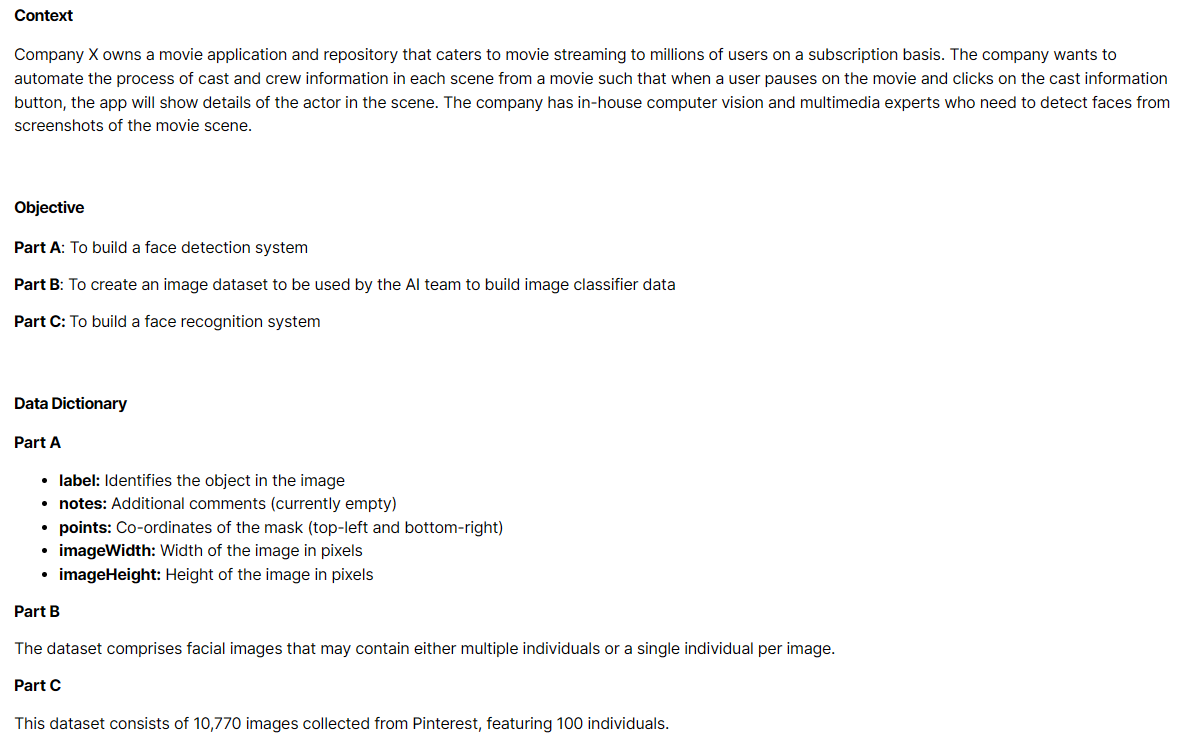

# **Part I:  Data Preprocessing and Visualization**

## Importing the Required Libraries

In [66]:
import cv2
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from zipfile import ZipFile

import tensorflow_datasets as tfds
from tensorflow.keras.applications.mobilenet import preprocess_input
# from tensorflow_examples.models.pix2pix import pix2pix ##  a module within the tensorflow_examples package that provides an implementation of the Pix2Pix model for image-to-image translation
tfds.disable_progress_bar() # This is called to disable the progress bar that is displayed by default when using the tensorflow_datasets package.

from IPython.display import clear_output
from sklearn.model_selection import train_test_split

from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.layers import Reshape, UpSampling2D, Concatenate, Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.backend import log
from tensorflow import reduce_sum
from tensorflow.keras.backend import epsilon
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the Dataset

In [85]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import the data "Images.npy"

In [86]:
file_path = r"/content/drive/MyDrive/Project/Images.npy"
data = np.load(file_path, allow_pickle=True)

In [87]:
print(f"Total samples loaded: {len(data)}")

Total samples loaded: 393


## View Some random images

array([[[42, 37, 34],
        [56, 51, 48],
        [71, 66, 63],
        ...,
        [23, 33, 34],
        [26, 36, 37],
        [28, 38, 39]],

       [[40, 35, 32],
        [51, 46, 43],
        [64, 59, 56],
        ...,
        [27, 36, 35],
        [24, 33, 32],
        [26, 35, 34]],

       [[43, 38, 35],
        [51, 46, 43],
        [61, 56, 53],
        ...,
        [28, 30, 27],
        [33, 35, 32],
        [35, 37, 34]],

       ...,

       [[56, 47, 40],
        [57, 48, 41],
        [61, 52, 45],
        ...,
        [67, 48, 42],
        [55, 35, 28],
        [60, 40, 33]],

       [[53, 44, 37],
        [54, 45, 38],
        [57, 48, 41],
        ...,
        [59, 40, 34],
        [60, 40, 33],
        [54, 34, 27]],

       [[53, 44, 37],
        [54, 45, 38],
        [57, 48, 41],
        ...,
        [59, 40, 34],
        [70, 50, 43],
        [64, 44, 37]]], dtype=uint8)
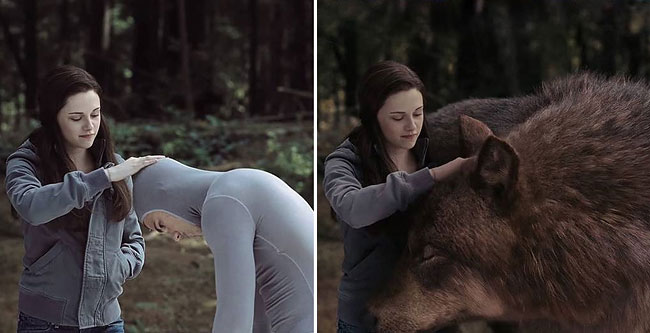

In [88]:
data[0][0]

array([[[ 6, 42, 56],
        [ 6, 42, 56],
        [ 6, 42, 56],
        ...,
        [ 9, 47, 60],
        [ 9, 47, 60],
        [ 9, 47, 60]],

       [[ 6, 42, 56],
        [ 6, 42, 56],
        [ 6, 42, 56],
        ...,
        [ 9, 47, 60],
        [ 9, 47, 60],
        [ 9, 47, 60]],

       [[ 6, 42, 56],
        [ 6, 42, 56],
        [ 6, 42, 56],
        ...,
        [ 9, 47, 60],
        [ 9, 47, 60],
        [ 9, 47, 60]],

       ...,

       [[ 3,  3,  3],
        [ 2,  2,  2],
        [ 2,  2,  2],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 1,  1,  1],
        ...,
        [ 8,  8,  8],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 9,  9,  9],
        [ 5,  5,  5],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 3,  3,  3],
        [ 4,  4,  4]]], dtype=uint8)
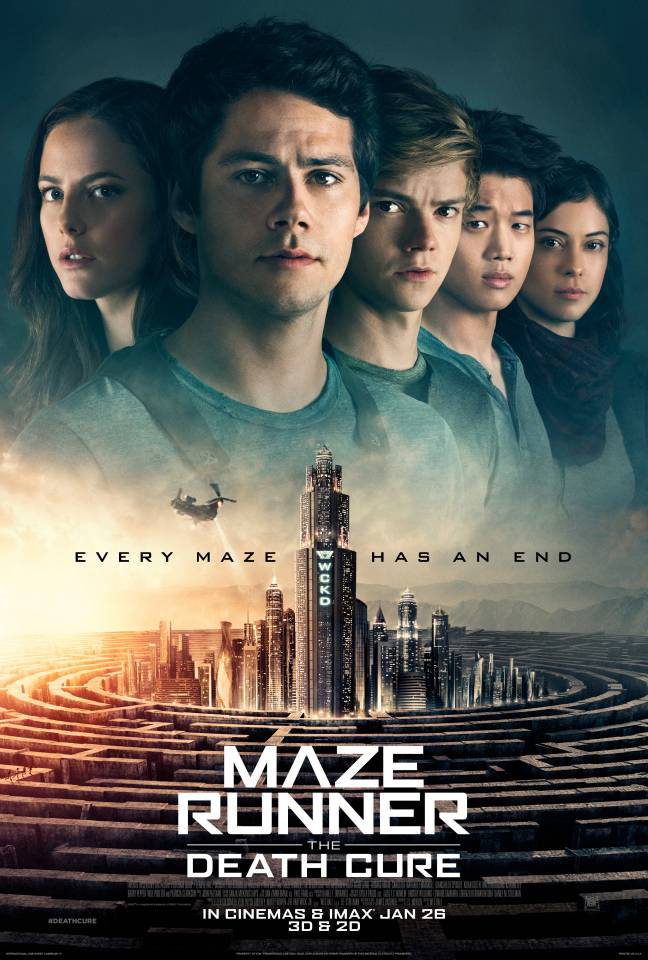

In [89]:
data[10][0]

array([[[106, 128, 149],
        [113, 135, 156],
        [112, 134, 155],
        ...,
        [125, 133, 154],
        [126, 134, 155],
        [126, 132, 154]],

       [[114, 136, 157],
        [102, 124, 145],
        [113, 135, 156],
        ...,
        [130, 138, 159],
        [120, 128, 149],
        [120, 128, 149]],

       [[112, 134, 155],
        [114, 136, 157],
        [110, 132, 153],
        ...,
        [121, 129, 150],
        [125, 133, 154],
        [127, 135, 156]],

       ...,

       [[ 77,  56,  53],
        [103,  82,  77],
        [ 63,  43,  36],
        ...,
        [ 59,  28,  36],
        [ 74,  41,  50],
        [ 63,  30,  39]],

       [[  8,   3,   0],
        [  6,   1,   0],
        [  7,   1,   3],
        ...,
        [ 66,  35,  43],
        [ 60,  27,  36],
        [ 59,  26,  35]],

       [[  5,  15,   7],
        [  7,  11,  10],
        [ 18,  16,  21],
        ...,
        [ 66,  33,  42],
        [ 65,  32,  41],
        [ 67,  34,  41]]], dtype=uint8)
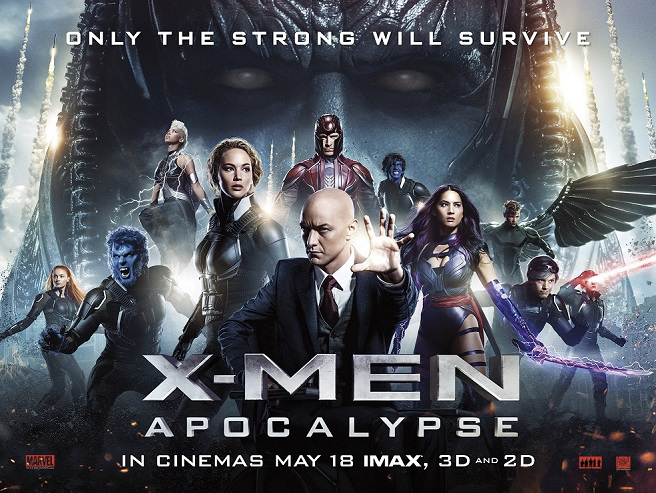

In [90]:
data[392][0]

## Split the images and their mask into two objects

In [99]:
image_height = IMAGE_HEIGHT = 224
image_width = IMAGE_WIDTH = 224

## Count of non-3 channel images

Image Index: 1, Shape: (697, 1280, 4)


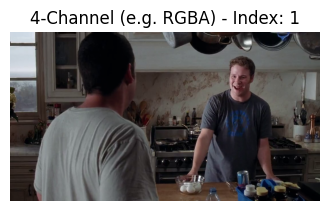

Image Index: 2, Shape: (291, 600, 4)


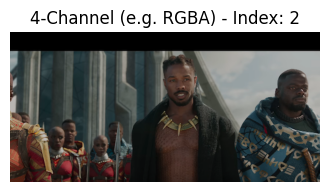

Image Index: 39, Shape: (340, 516, 4)


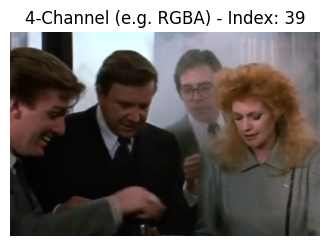

Image Index: 47, Shape: (600, 800, 4)


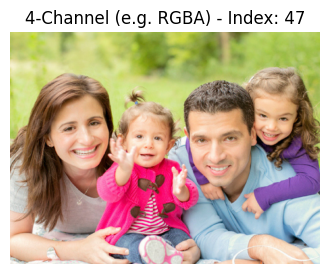

Image Index: 62, Shape: (312, 750, 4)


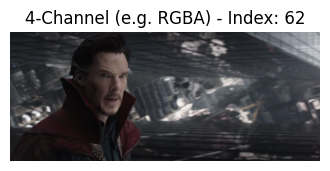


 Total images with non-3 channels found: 5


In [100]:
import matplotlib.pyplot as plt

count = 0  # Count of non-3 channel images

for index in range(len(data)):
    img = data[index][0]

    # Proceed only if image has 3 dimensions (height, width, channels)
    if img.ndim == 3 and img.shape[2] != 3:
        count += 1
        print(f"Image Index: {index}, Shape: {img.shape}")

        # Prepare image for display
        if img.shape[2] > 3:
            # More than 3 channels (e.g., RGBA), slice to RGB
            img_to_display = img[:, :, :3]
            title = f"{img.shape[2]}-Channel (e.g. RGBA)"
        elif img.shape[2] < 3:
            # Less than 3 channels (e.g., grayscale), replicate to RGB
            img_to_display = img
            if img.shape[2] == 1:
                img_to_display = img.repeat(3, axis=2)  # Expand channel
            title = f"{img.shape[2]}-Channel (e.g. Grayscale)"
        else:
            img_to_display = img
            title = f"{img.shape[2]}-Channel"

        # Display
        plt.figure(figsize=(4, 4))
        plt.imshow(img_to_display.astype('uint8'))  # Safe display
        plt.title(f"{title} - Index: {index}")
        plt.axis('off')
        plt.show()

        if count >= 5:  # Limit number of images to show
            break

print(f"\n Total images with non-3 channels found: {count}")


## Resize the images and masks to the same shape and visualize the original and masked images

In [102]:
masks = np.zeros((int(data.shape[0]), image_height, image_width))
images = np.zeros((int(data.shape[0]), image_height, image_width, 3))
for index in range(data.shape[0]):
    img = data[index][0]
    img = cv2.resize(img, dsize=(image_height, image_width), interpolation=cv2.INTER_CUBIC)
    try:
      img = img[:, :, :3]
    except:
      continue
    images[index] = preprocess_input(np.array(img, dtype=np.float32))
    for i in data[index][1]:
        x1 = int(i["points"][0]['x'] * image_width)
        x2 = int(i["points"][1]['x'] * image_width)
        y1 = int(i["points"][0]['y'] * image_height)
        y2 = int(i["points"][1]['y'] * image_height)
        masks[index][y1:y2, x1:x2] = 1

In [103]:
print('Shape of images: ', images.shape)

Shape of images:  (393, 224, 224, 3)


In [104]:
print('Shape of mask array: ', masks.shape)

Shape of mask array:  (393, 224, 224)


[[[-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]
  ...
  [-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]]

 [[-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]
  ...
  [-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]]

 [[-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]
  ...
  [-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]]

 ...

 [[-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]
  ...
  [-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]]

 [[-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]
  ...
  [-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]]

 [[-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]
  ...
  [-1. -1. -1.]
  [-1. -1. -1.]
  [-1. -1. -1.]]]


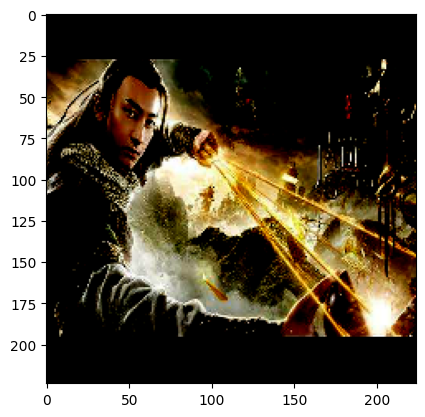

In [105]:
ran_img1 = 20

print(images[ran_img1])
plt.imshow(images[ran_img1]);

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


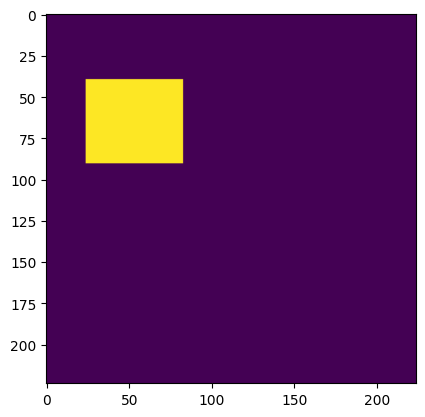

In [106]:
print(masks[ran_img1])
plt.imshow(masks[ran_img1]);

Image array: [[[-0.95294118 -0.67058825 -0.56078434]
  [-0.95294118 -0.67058825 -0.56078434]
  [-0.95294118 -0.67058825 -0.56078434]
  ...
  [-0.92941177 -0.63137257 -0.52941179]
  [-0.92941177 -0.63137257 -0.52941179]
  [-0.92941177 -0.63137257 -0.52941179]]

 [[-0.95294118 -0.67058825 -0.56078434]
  [-0.95294118 -0.67058825 -0.56078434]
  [-0.95294118 -0.67058825 -0.56078434]
  ...
  [-0.92941177 -0.63137257 -0.52941179]
  [-0.92941177 -0.63137257 -0.52941179]
  [-0.92941177 -0.63137257 -0.52941179]]

 [[-0.95294118 -0.67058825 -0.56078434]
  [-0.95294118 -0.67058825 -0.56078434]
  [-0.95294118 -0.67058825 -0.56078434]
  ...
  [-0.92941177 -0.63137257 -0.52941179]
  [-0.92941177 -0.63137257 -0.52941179]
  [-0.92941177 -0.63137257 -0.52941179]]

 ...

 [[-0.99215686 -0.99215686 -0.99215686]
  [-0.99215686 -0.99215686 -0.99215686]
  [-0.99215686 -0.99215686 -0.99215686]
  ...
  [-0.99215686 -0.99215686 -0.99215686]
  [-0.99215686 -0.99215686 -0.99215686]
  [-0.99215686 -0.99215686 -0.9

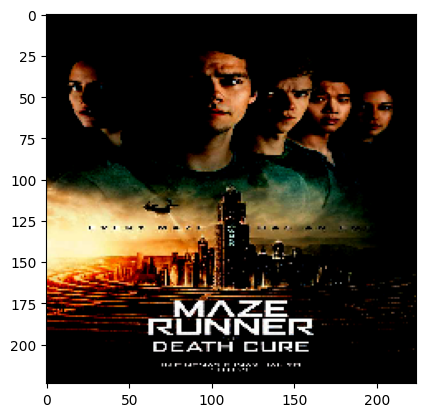

In [107]:
ran_img2 = 10
print("Image array:", images[ran_img2])
plt.imshow(images[ran_img2]);

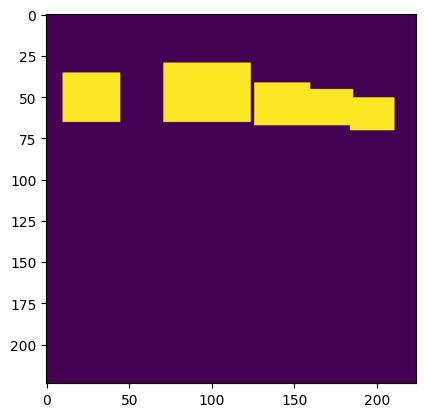

In [108]:
plt.imshow(masks[ran_img]);

## Split the data into train and test

In [109]:
# Split data into train and test sets
images_train, images_test, masks_train, masks_test = train_test_split(images, masks, test_size=0.2, random_state=42)

In [110]:
print("images_train shape  =>", images_train.shape)
print("images_test shape   =>", images_test.shape)
print("masks_train shape   =>", masks_train.shape)
print("masks_test shape    =>", masks_test.shape)

images_train shape  => (314, 224, 224, 3)
images_test shape   => (79, 224, 224, 3)
masks_train shape   => (314, 224, 224)
masks_test shape    => (79, 224, 224)


# **Part I: Model Building and Evaluation**

## Design a face mask detection model

In [111]:
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.layers import Reshape, UpSampling2D, Concatenate, Conv2D
from tensorflow.keras.models import Model

def create_model(trainable=True):
    model = MobileNet(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), include_top=False, alpha=1.0, weights="imagenet")

    for layer in model.layers:
        layer.trainable = trainable

    block0 = model.get_layer("conv_pw_1_relu").output
    block1 = model.get_layer("conv_pw_3_relu").output
    block2 = model.get_layer("conv_pw_5_relu").output
    block3 = model.get_layer("conv_pw_11_relu").output
    block4 = model.get_layer("conv_pw_13_relu").output

    x = Concatenate()([UpSampling2D()(block4), block3])
    print(x.shape)
    x = Concatenate()([UpSampling2D()(x), block2])
    print(x.shape)
    x = Concatenate()([UpSampling2D()(x), block1])
    print(x.shape)
    x = Concatenate()([UpSampling2D()(x), block0])
    print(x.shape)
    x = UpSampling2D()(x)
    print(x.shape)
    x = Conv2D(1, kernel_size=1, activation="sigmoid")(x)
    x = Reshape((IMAGE_HEIGHT, IMAGE_WIDTH))(x)
    print(x.shape)

    return Model(inputs=model.input, outputs=x)

In [112]:
model = create_model()

(None, 14, 14, 1536)
(None, 28, 28, 1792)
(None, 56, 56, 1920)
(None, 112, 112, 1984)
(None, 224, 224, 1984)
(None, 224, 224)


In [113]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_1           │ (None, 112, 112,  │        288 │ conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_1_bn        │ (None, 112, 112,  │        128 │ conv_dw_1[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_1_relu      │ (None, 112, 112,  │          0 │ conv_dw_1_bn[0][… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_1 (Conv2D)  │ (None, 112, 112,  │      2,048 │ conv_dw_1_relu[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_1_bn        │ (None, 112, 112,  │        256 │ conv_pw_1[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_1_relu      │ (None, 112, 112,  │          0 │ conv_pw_1_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pad_2          │ (None, 113, 113,  │          0 │ conv_pw_1_relu[0… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_2           │ (None, 56, 56,    │        576 │ conv_pad_2[0][0]  │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_2_bn        │ (None, 56, 56,    │        256 │ conv_dw_2[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_2_relu      │ (None, 56, 56,    │          0 │ conv_dw_2_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_2 (Conv2D)  │ (None, 56, 56,    │      8,192 │ conv_dw_2_relu[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_2_bn        │ (None, 56, 56,    │        512 │ conv_pw_2[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_2_relu      │ (None, 56, 56,    │          0 │ conv_pw_2_bn[0][

 Total params: 3,230,849 (12.32 MB)

 Trainable params: 3,208,961 (12.24 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [ ]:
def dice_coeff(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    score = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
    return score

- This is a function that calculates the dice coefficient between the predicted and true masks in a segmentation task. The dice coefficient is a common evaluation metric for image segmentation, which measures the overlap between two binary masks. It is calculated as twice the intersection of the predicted and true masks divided by the sum of the number of pixels in both masks.

- The function takes two arguments, y_true and y_pred, which are the ground truth and predicted masks, respectively. The function first flattens both masks into 1D arrays using tf.reshape(). Then, it calculates the intersection of the two masks by element-wise multiplication of the flattened arrays and summing the result. Next, it calculates the sum of pixels in both masks using tf.reduce_sum(). Finally, it applies the dice coefficient formula and returns the result. The smooth variable is used to avoid division by zero errors when both masks are empty.

In [ ]:
def dice_loss(y_true, y_pred):
    loss = 1 - dice_coeff(y_true, y_pred)
    return loss

In [ ]:
from tensorflow.python.keras import losses

def bce_dice_loss(y_true, y_pred):
    loss = losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)
    return loss

- This function computes the sum of binary cross-entropy loss and Dice coefficient loss between the true and predicted masks. The binary cross-entropy loss measures the difference between the predicted and true masks pixel-wise. The Dice coefficient loss measures the overlap between the predicted and true masks. By summing these two losses, the model is encouraged to predict masks that are both accurate and have high overlap with the true masks.

In [ ]:
model.compile(loss=bce_dice_loss, optimizer='adam', metrics=[dice_loss, dice_coeff, 'accuracy'])

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("model-{loss:.2f}.weights.h5",
                              monitor="loss",
                              verbose=1,
                              save_best_only=True,
                              save_weights_only=True,
                              mode="min")


stop = EarlyStopping(monitor="loss",
                     patience=3,
                     mode="min")


learning_rate_reduction = ReduceLROnPlateau(monitor='loss',
                                            patience=3,
                                            verbose=1,
                                            factor=0.3,
                                            min_lr=0.00001,
                                            mode="min")

In [ ]:
epochs = 10
batch_size = 1

In [ ]:
history = model.fit(images_train, masks_train, batch_size= batch_size, epochs= epochs, callbacks=[checkpoint, learning_rate_reduction, stop])

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficient: 0.4278 - loss: 1.6480
Epoch 1: loss improved from inf to 1.36466, saving model to model-1.36.weights.h5
314/314 ━━━━━━━━━━━━━━━━━━━━ 627s 2s/step - dice_coefficient: 0.4280 - loss: 1.6471 - learning_rate: 0.0010
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficient: 0.6101 - loss: 0.8271
Epoch 2: loss improved from 1.36466 to 0.85395, saving model to model-0.85.weights.h5
314/314 ━━━━━━━━━━━━━━━━━━━━ 604s 2s/step - dice_coefficient: 0.6100 - loss: 0.8272 - learning_rate: 0.0010
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficient: 0.6619 - loss: 0.6706
Epoch 3: loss improved from 0.85395 to 0.70154, saving model to model-0.70.weights.h5
314/314 ━━━━━━━━━━━━━━━━━━━━ 617s 2s/step - dice_coefficient: 0.6619 - loss: 0.6707 - learning_rate: 0.0010
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficient: 0.7108 - loss: 0.5391
Epoch 4: loss improved from 0.70154 to 0.59995, sa

## Predict and visualize the masks for the test images

In [160]:
def predict(image_index):
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))

    # Original Image
    orig_img = images_test[image_index]
    axs[0].imshow(orig_img)
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    # Ground Truth Mask
    axs[1].imshow(masks_test[image_index])
    axs[1].set_title("Ground Truth Mask")
    axs[1].axis('off')

    # Resize image for prediction
    image_height, image_width = orig_img.shape[:2]
    resized_img = cv2.resize(orig_img, (224, 224))  # Resize to model input
    input_img = resized_img.reshape(1, 224, 224, 3)

    # Model Prediction
    raw_pred = model.predict(input_img)[0]  # shape (256, 256, 1) or (256, 256)
    axs[2].imshow(raw_pred.squeeze(), cmap='gray')  # Handle single-channel mask
    axs[2].set_title("Raw Predicted Mask")
    axs[2].axis('off')

    # Resize predicted mask back to original size
    pred_mask = (raw_pred > 0.5).astype(np.float32)
    pred_mask_resized = cv2.resize(pred_mask.squeeze(), (image_width, image_height))

    # Overlay Prediction
    axs[3].imshow(orig_img)
    axs[3].imshow(pred_mask_resized, alpha=0.6, cmap='jet')
    axs[3].set_title("Overlay: Predicted Mask")
    axs[3].axis('off')

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step


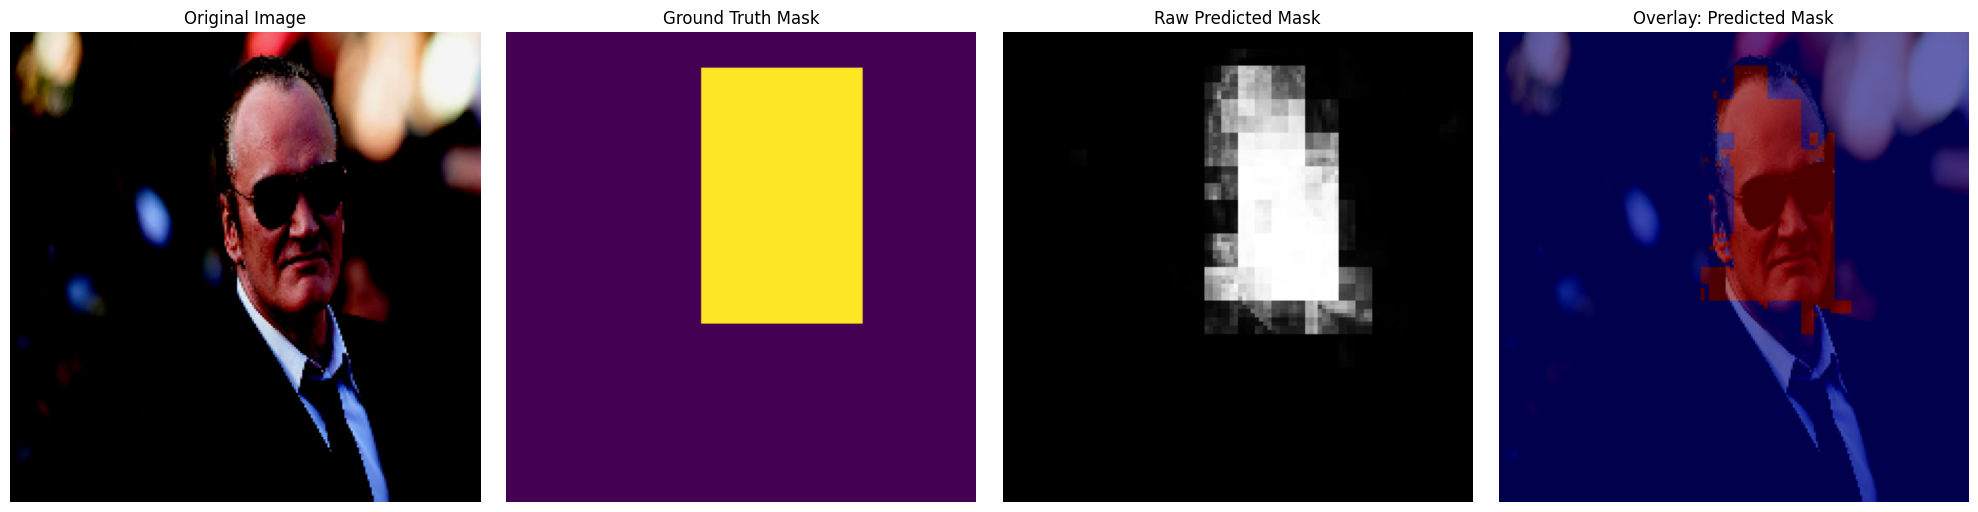

In [161]:
predict(13)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


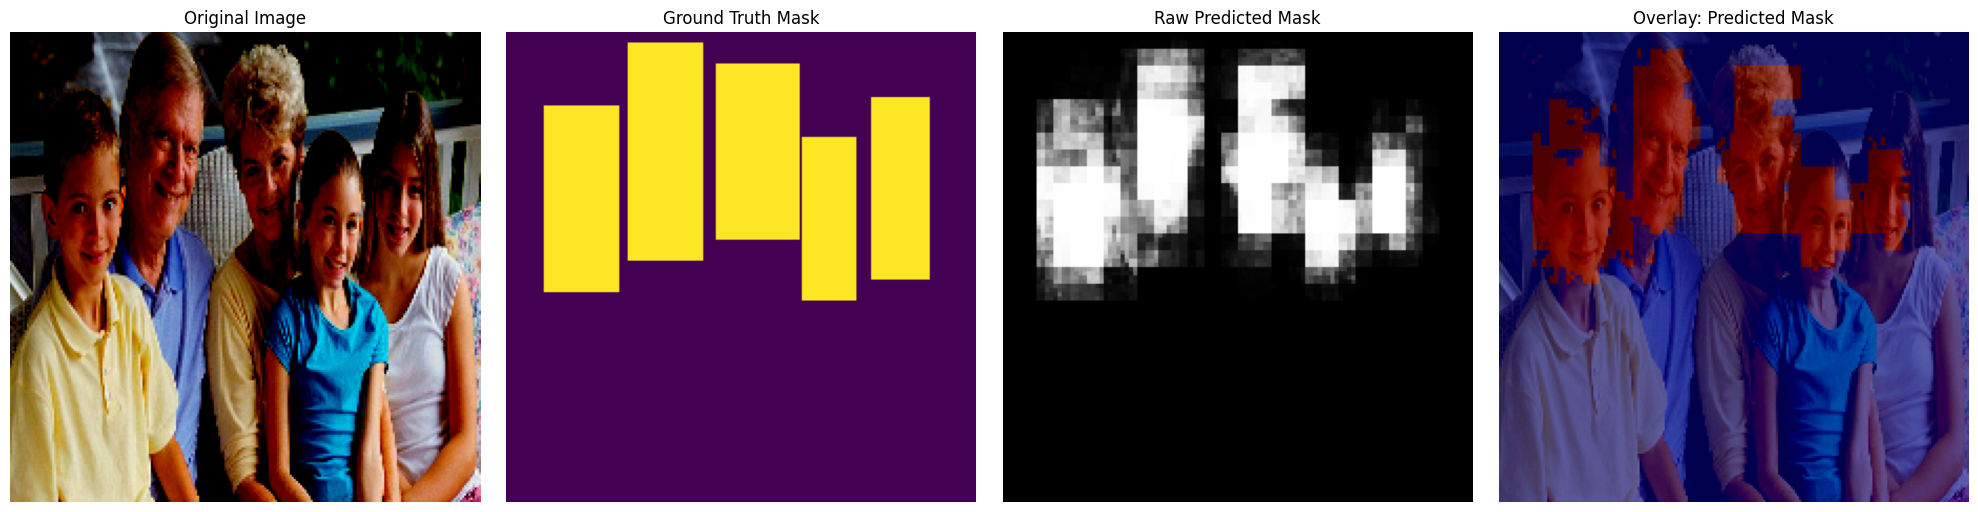

In [162]:
predict(25)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step


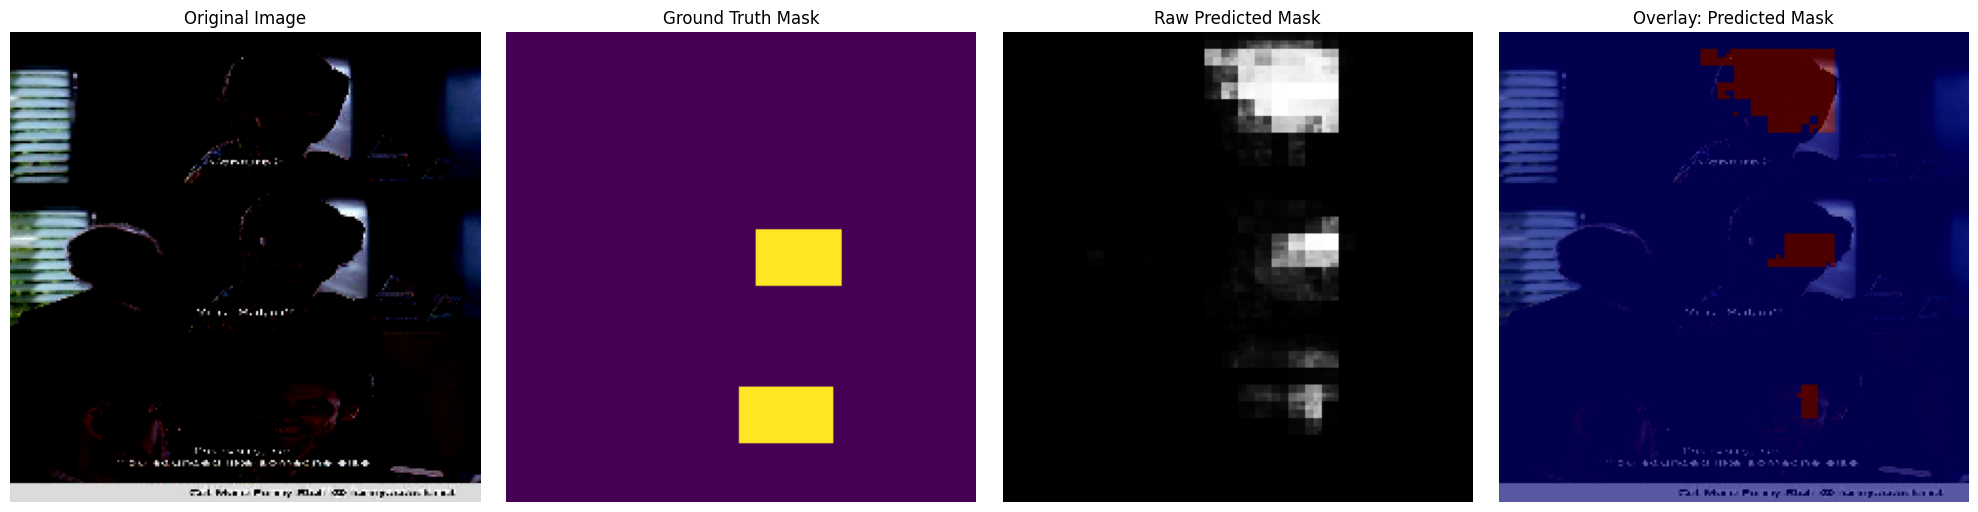

In [173]:
predict(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step


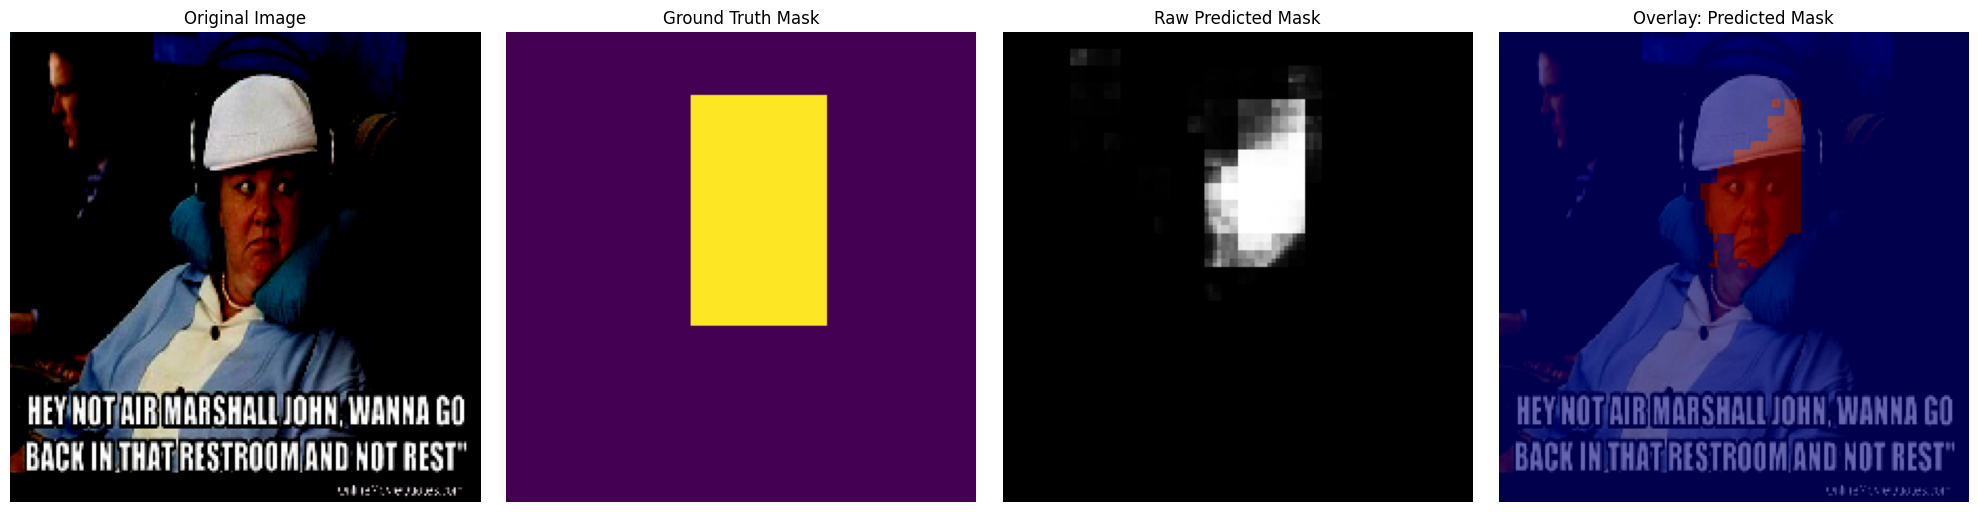

In [174]:
predict(78)

## Evaluate and share insights on performance of the model

In [178]:
# Evaluate the model.
score = model.evaluate(images_test, masks_test, verbose=1, batch_size = batch_size)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

79/79 ━━━━━━━━━━━━━━━━━━━━ 49s 611ms/step - dice_coefficient: 0.5037 - loss: 1.4838
Test loss: 1.3900572061538696
Test accuracy: 0.5304628014564514


### Observations

- The model achieved a test loss of 1.390 and a test accuracy of 0.530.

- A higher test loss suggests that the model's predictions are less accurate, and a test accuracy of around 53% indicates that the model is correctly classifying just over half of the test data. These results highlight room for improvement in both model performance and generalization.

# **Part I: Predicting Face Masks from Images**

## Import images from folder ‘training_images’

In [ ]:
zip_file_path = r"/content/drive/MyDrive/Project/training_images-20211126T092819Z-001.zip"
unzip_dir = r"/content/drive/MyDrive/Project/training_images"
csv_output  = r"/content/drive/MyDrive/Project/faces_metadata.csv"

In [ ]:
def unzip_images(zip_path: str, dest_dir: str) -> None:
    """Unzip a .zip archive to `dest_dir` if not already unzipped."""
    if not os.path.isdir(dest_dir):
        print(f"Unzipping {zip_path} → {dest_dir}")
        with ZipFile(zip_path, 'r') as z:
            z.extractall(dest_dir)
    else:
        print(f"Folder '{dest_dir}' already exists — skipping unzip.")

In [ ]:
unzip_images(zip_file_path, unzip_dir)

Unzipping /content/drive/MyDrive/Project/training_images-20211126T092819Z-001.zip → /content/drive/MyDrive/Project/training_images


In [ ]:
def load_image_paths(folder: str, exts: tuple[str, ...] = (".jpg", ".png", ".jpeg")) -> list[str]:
    """Return a list of absolute image paths in a folder (filtered by ext)."""
    return [
        os.path.join(folder, fname)
        for fname in os.listdir(folder)
        if fname.lower().endswith(exts)
    ]

In [ ]:
img_paths = load_image_paths(unzip_dir)

## Extract metadata for the faces in all the images

In [ ]:
def build_face_metadata(image_paths: list[str]) -> list[dict]:
    """Loop through images and collect face bounding‐box metadata."""
    meta = []
    for path in image_paths:
        img = cv2.imread(path)
        if img is None:
            print(f"[WARN] cannot read {path} — skipped")
            continue

        for (x, y, w, h) in detect_faces(img):
            meta.append({
                "Image": os.path.basename(path),
                "Face_X": x,
                "Face_Y": y,
                "Face_Width": w,
                "Face_Height": h
            })
    return meta

In [ ]:
face_meta = build_face_metadata(img_paths)

## Detect faces

In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def detect_faces(img_bgr) -> list[tuple[int, int, int, int]]:
    """Detect faces and return bounding boxes (x, y, w, h)."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    bboxes = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    return bboxes

## Write and save it into a DataFrame

In [ ]:
def save_metadata(face_meta: list[dict], csv_path: str) -> None:
    df = pd.DataFrame(face_meta)
    df.to_csv(csv_path, index=False)
    print(f"[OK] Saved {len(df)} face records → {csv_path}")

In [ ]:
save_metadata(face_meta, csv_output)

[OK] Saved 0 face records → /content/drive/MyDrive/Project/faces_metadata.csv


# **Part II: Data Preprocessing**

## Import the data ‘PINS.zip’

In [ ]:
from zipfile import ZipFile

pins_file_path = "/content/drive/MyDrive/Project/PINS.zip"
extract_dir = "/content/drive/MyDrive/Project"

with ZipFile(pins_file_path, 'r') as zip_ref:
    zip_ref.extractall(path=extract_dir)


## Read the images and extract labels from the filenames for all the folders

In [ ]:
# Function to create metadata of the image

import numpy as np
import os

class IdentityMetadata():
    def __init__(self, base, name, file):
        # print(base, name, file)
        # dataset base directory
        self.base = base
        # identity name
        self.name = name
        # image file name
        self.file = file

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.base, self.name, self.file)



In [ ]:
# Call load_metadata to read the images and assign metadata to a variable

def load_metadata(path):
    metadata = []
    for i in os.listdir(path):
        for f in os.listdir(os.path.join(path, i)):
            # Check file extension. Allow only jpg/jpeg' files.
            ext = os.path.splitext(f)[1]
            if ext == '.jpg' or ext == '.jpeg':
                metadata.append(IdentityMetadata(path, i, f))
    return np.array(metadata)

metadata = load_metadata(f"{extract_dir}/PINS")

In [ ]:
# Write a function to read image using opencv and convert it from BGR to RGB

import cv2
def load_image(path):
    img = cv2.imread(path, 1)
    # OpenCV loads images with color channels
    # in BGR order. So we need to reverse them
    return img[...,::-1]

array([[[233, 188, 165],
        [231, 186, 163],
        [220, 178, 156],
        ...,
        [106,  63,  72],
        [106,  63,  72],
        [106,  63,  72]],

       [[232, 187, 164],
        [233, 188, 165],
        [220, 178, 156],
        ...,
        [106,  63,  72],
        [106,  63,  72],
        [106,  63,  72]],

       [[230, 186, 161],
        [228, 184, 159],
        [206, 164, 140],
        ...,
        [106,  63,  72],
        [106,  63,  72],
        [106,  63,  72]],

       ...,

       [[198, 118,  91],
        [197, 120,  94],
        [195, 119,  95],
        ...,
        [ 78,  66,  76],
        [ 78,  66,  76],
        [ 78,  66,  76]],

       [[200, 120,  93],
        [200, 120,  93],
        [198, 121,  95],
        ...,
        [ 78,  66,  76],
        [ 78,  66,  76],
        [ 78,  66,  76]],

       [[201, 121,  94],
        [201, 121,  94],
        [199, 122,  96],
        ...,
        [ 78,  66,  76],
        [ 78,  66,  76],
        [ 78,  66,  76]]], dtype=uint8)
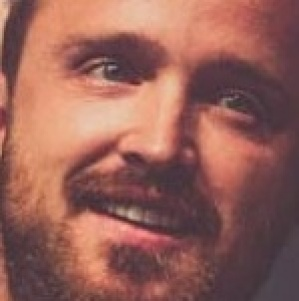

In [ ]:
load_image(metadata[0].image_path())

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
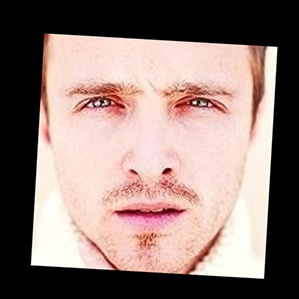

In [ ]:
load_image(metadata[1].image_path())

# **Part II: Visualizing Similar Images**

## Generate embedding vectors for each image in the dataset

In [ ]:
vgg_file_path = r"/content/drive/MyDrive/Project/vgg_face_weights.h5"

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ZeroPadding2D, Convolution2D, MaxPooling2D, Dropout, Flatten, Activation

def vgg_face():
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))

    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model

In [ ]:
model = vgg_face()
model.load_weights(vgg_file_path)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras.models import Model
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

In [ ]:
# Get embedding vector for first image in the metadata using the pre-trained model

img_path = metadata[0].image_path()
img = load_image(img_path)

# Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]
img = (img / 255.).astype(np.float32)

img = cv2.resize(img, dsize = (224,224))
print(img.shape)

# Obtain embedding vector for an image
# Get the embedding vector for the above image using vgg_face_descriptor model and print the shape

embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
print(embedding_vector.shape)

(224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
(2622,)


- Writing code to iterate through metadata and create embeddings for each image using vgg_face_descriptor.predict() and storing in a list with name embeddings

- If there is any error in reading any image in the dataset, we will fill the emebdding vector of that image with 2622-zeroes as the final embedding from the model is of length 2622.

In [ ]:
embeddings = np.zeros((metadata.shape[0], 2622))

for i, m in enumerate(metadata):
    try:
        img = load_image(m.image_path())
        # scale RGB values to interval [0,1]
        img = cv2.resize(img, dsize = (224,224))
        img = (img / 255.).astype(np.float32)
        # obtain embedding vector for image
        embeddings[i] = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
    except Exception as e:
        print(str(e))
        print(i,m)

Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 971ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━

## Choose a distance metric and use it along with a threshold to display similar and dissimilar images

### Function to calculate distance between given 2 pairs of images.

- Consider distance metric as "Squared L2 distance"
- Squared l2 distance between 2 points (x1, y1) and (x2, y2) = (x1-x2)^2 + (y1-y2)^2

In [ ]:
def distance(emb1, emb2):
  return np.sum(np.square(emb1 - emb2))

### Plot images and get distance between the pairs given below
- 2, 3 and 2, 180
- 30, 31 and 30, 100
- 70, 72 and 70, 115

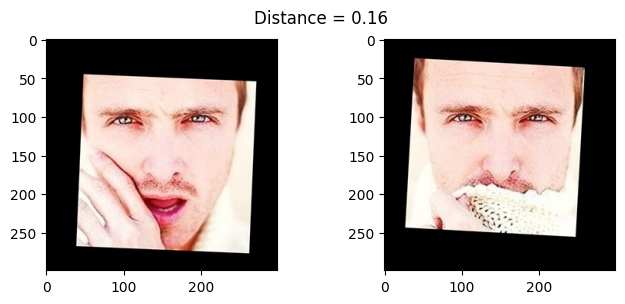

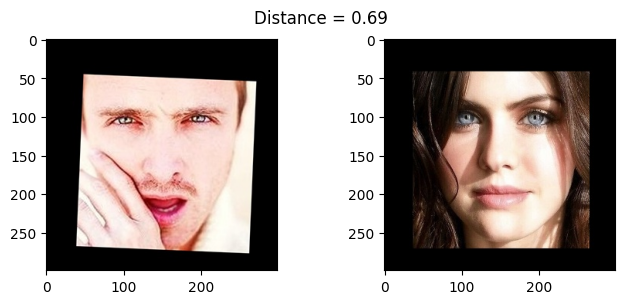

In [ ]:
import matplotlib.pyplot as plt

def show_pair(idx1, idx2):
    plt.figure(figsize=(8,3))
    plt.suptitle(f'Distance = {distance(embeddings[idx1], embeddings[idx2]):.2f}')
    plt.subplot(121)
    plt.imshow(load_image(metadata[idx1].image_path()))
    plt.subplot(122)
    plt.imshow(load_image(metadata[idx2].image_path()));

show_pair(2, 3)
show_pair(2, 180)

# **Part III: Model Building and Inference**

## Apply PCA on the embedding vectors

- Create X_train, X_test and y_train, y_test
- Use train_idx to seperate out training features and labels
- Use test_idx to seperate out testing features and labels

In [ ]:
train_idx = np.arange(metadata.shape[0]) % 9 != 0
test_idx = np.arange(metadata.shape[0]) % 9 == 0

# one half as train examples of 10 identities
X_train = embeddings[train_idx]
# another half as test examples of 10 identities
X_test = embeddings[test_idx]

targets = np.array([m.name for m in metadata])
y_train = targets[train_idx]
y_test = targets[test_idx]

- Encode the targets
- Use LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Numerical encoding of identities
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

- Scale the features using StandardScaler

In [ ]:
# Standarize features
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

- Reduce feature dimensions using Principal Component Analysis
- Set the parameter n_components=128

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=128, svd_solver='randomized', whiten=True)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

## Build and train a SVM classifier on top of it

In [ ]:
from sklearn.svm import SVC

clf = SVC(kernel='rbf', class_weight=None , C=10000000, gamma='auto')
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9640768588137009

## Use the trained SVM model to predict the labels of the test images

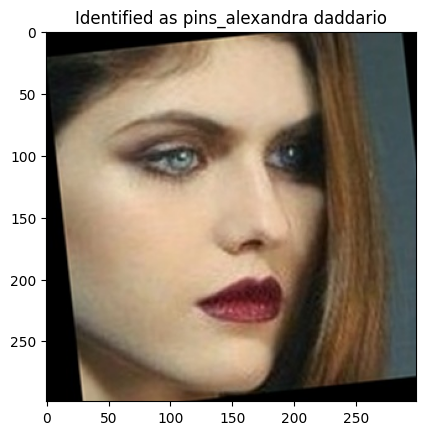

In [ ]:
example_idx = 10

example_image = load_image(metadata[test_idx][example_idx].image_path())
example_prediction = clf.predict([X_test[example_idx]])
example_identity = encoder.inverse_transform(example_prediction)[0]

plt.imshow(example_image)
plt.title(f'Identified as {example_identity}');

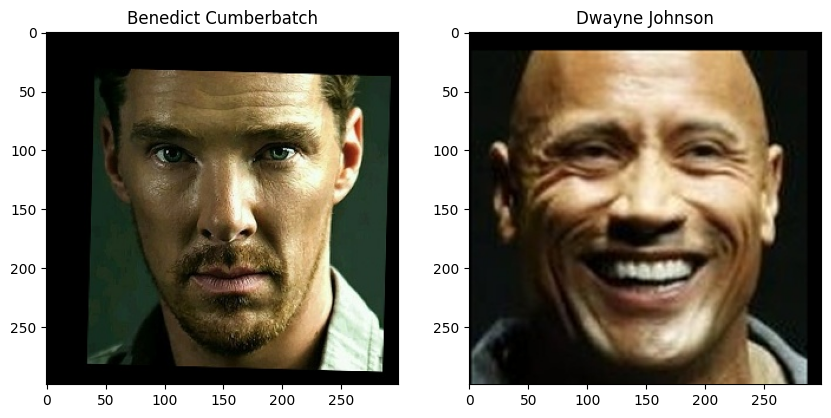

In [ ]:
# Import and display the the test images

# Load the test images
image1 = load_image(r"/content/drive/MyDrive/Project/Benedict Cumberbatch9.jpg")
image2 = load_image(r"/content/drive/MyDrive/Project/Dwayne Johnson4.jpg")

# Display the test images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title('Benedict Cumberbatch')
plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title('Dwayne Johnson')
plt.show()

# **Actionable Insights & Recommendations**

### **Insights from the Analysis Conducted:**

- The SVM classifier built on PCA-reduced embeddings achieved 96.4% accuracy, significantly outperforming the base model (53%), highlighting the importance of proper feature representation.

- Only a few misclassifications were observed, showing the model's strong ability to generalize on unseen test images.

- Significant improvement in accuracy after applying PCA for dimensionality reduction, confirming its effectiveness in removing noise and redundant features from embeddings.

### **Actionable Business Recommendations:**

- Use pre-trained embeddings + PCA + SVM as the default pipeline for face recognition tasks to ensure high accuracy.

- Replace Haar Cascade with deep learning-based detectors for more reliable face detection across diverse image conditions.

- Implement a quality check on input images (channels, resolution) during preprocessing to avoid data loss and improve detection success.